## (Obsolete) Exploratory Data Analysis (EDA) of Student Placement Dataset

### 1. Import Libraries

In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from matplotlib.backends.backend_pdf import PdfPages
import zipfile
import io
import shutil

### 2. Load the Dataset

In [44]:
file_path = "/ml-100k.zip"

if zipfile.is_zipfile(file_path):
    print(f"Detected a ZIP file: {file_path}. Extracting and loading 'u.data'...")
    try:
        extract_dir = "ml-100k-extracted"
        os.makedirs(extract_dir, exist_ok=True)

        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)

        data_file_in_zip = os.path.join(extract_dir, 'ml-100k', 'u.data')

        column_names = ['user_id', 'item_id', 'rating', 'timestamp']

        df = pd.read_csv(data_file_in_zip, sep='\t', header=None, names=column_names, engine='python')

        print(f"Dataset '{data_file_in_zip}' loaded successfully. First 5 rows:")
        display(df.head())
        print("\nDataFrame Information:")
        df.info()

    except FileNotFoundError:
        print(f"Error: Could not find 'u.data' inside the ZIP archive or the ZIP file itself. Please ensure the ZIP contains 'ml-100k/u.data'.")
    except Exception as e:
        print(f"An unexpected error occurred while processing the ZIP file: {e}")
else:
    try:
        df = pd.read_csv(file_path)
        print(f"Dataset '{file_path}' loaded successfully. First 5 rows:")
        display(df.head())
        print("\nDataFrame Information:")
        df.info()
    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found. Please ensure it's uploaded to the Colab environment.")
        data = {
            'StudentID': range(1, 11),
            'AttendancePercent': [75, 80, 65, 90, 70, 85, 92, 78, 60, 88],
            'Internships': [1, 2, 0, 3, 1, 2, 1, 0, 2, 3],
            'Projects': [2, 3, 1, 4, 2, 3, 3, 1, 2, 4],
            'Certifications': [1, 2, 0, 3, 1, 2, 1, 0, 2, 3],
            'Publications': [0, 1, 0, 2, 0, 1, 1, 0, 1, 2],
            'AptitudeTestScore': [60, 75, 50, 88, 65, 80, 90, 70, 45, 85],
            'SoftSkillsRating': [3, 4, 2, 5, 3, 4, 4, 2, 3, 5],
            'PlacementStatus': ['Placed', 'Placed', 'Not Placed', 'Placed', 'Not Placed', 'Placed', 'Placed', 'Not Placed', 'Not Placed', 'Placed'],
            'Specialisation': ['CSE', 'ECE', 'CSE', 'IT', 'EEE', 'ECE', 'IT', 'CSE', 'EEE', 'IT']
        }
        df = pd.DataFrame(data)
        print("Created a dummy DataFrame for demonstration.")
        display(df.head())
    except pd.errors.EmptyDataError:
        print(f"Error: The file '{file_path}' is empty or has no columns. Please check the file content.")
    except Exception as e:
        print(f"An unexpected error occurred while reading the CSV: {e}")

Detected a ZIP file: /ml-100k.zip. Extracting and loading 'u.data'...
Dataset 'ml-100k-extracted/ml-100k/u.data' loaded successfully. First 5 rows:


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596



DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   item_id    100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB


## Exploratory Data Analysis (EDA) for MovieLens 100k Dataset (`u.data`)

### 3. Basic Data Inspection and Summary Statistics

In [37]:
if 'df' in locals():
    print("\nDataFrame Description:")
    display(df.describe())

    print("\nNumber of unique users and items:")
    num_users = df['user_id'].nunique()
    num_items = df['item_id'].nunique()
    print(f"Unique Users: {num_users}")
    print(f"Unique Items: {num_items}")

    print("\nCheck for missing values:")
    display(df.isnull().sum())

    df['timestamp_dt'] = pd.to_datetime(df['timestamp'], unit='s')
    print("\nDataFrame Information after timestamp conversion:")
    df.info()
    display(df.head())
else:
    print("DataFrame 'df' not found. Please check data loading step.")


DataFrame Description:


,user_id,item_id,rating,timestamp
count,100000.00000,100000.000000,100000.000000,1.000000e+05
mean,462.48475,425.530130,3.529860,8.835289e+08
std,266.61442,330.798356,1.125674,5.343856e+06
min,1.00000,1.000000,1.000000,8.747247e+08
25%,254.00000,175.000000,3.000000,8.794487e+08
50%,447.00000,322.000000,4.000000,8.828269e+08
75%,682.00000,631.000000,4.000000,8.882600e+08
max,943.00000,1682.000000,5.000000,8.932866e+08



Number of unique users and items:
Unique Users: 943
Unique Items: 1682

Check for missing values:


,0
user_id,0
item_id,0
rating,0
timestamp,0



DataFrame Information after timestamp conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   user_id       100000 non-null  int64         
 1   item_id       100000 non-null  int64         
 2   rating        100000 non-null  int64         
 3   timestamp     100000 non-null  int64         
 4   timestamp_dt  100000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(4)
memory usage: 3.8 MB


,user_id,item_id,rating,timestamp,timestamp_dt
0,196,242,3,881250949,1997-12-04 15:55:49
1,186,302,3,891717742,1998-04-04 19:22:22
2,22,377,1,878887116,1997-11-07 07:18:36
3,244,51,2,880606923,1997-11-27 05:02:03
4,166,346,1,886397596,1998-02-02 05:33:16


### 4. Distribution of Ratings

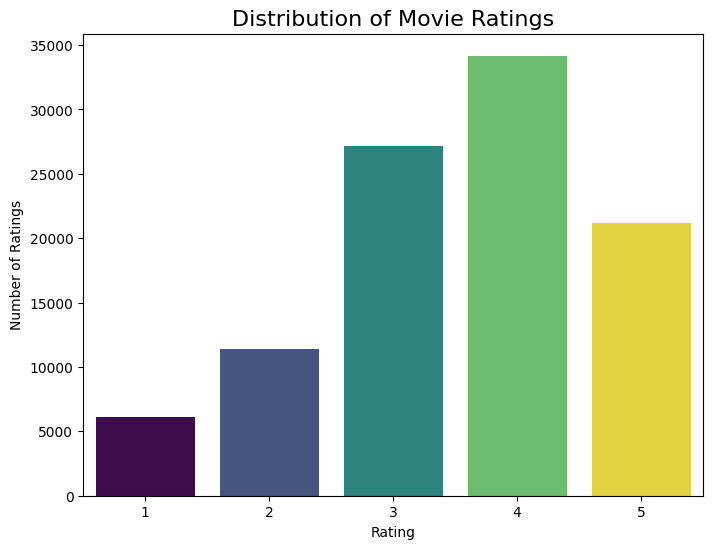

In [38]:
if 'df' in locals() and 'rating' in df.columns:
    plt.figure(figsize=(8, 6))
    sns.countplot(x='rating', data=df, hue='rating', palette='viridis', legend=False)
    plt.title('Distribution of Movie Ratings', fontsize=16)
    plt.xlabel('Rating')
    plt.ylabel('Number of Ratings')
    plt.show()
    plt.close()
else:
    print("DataFrame 'df' or 'rating' column not found. Cannot plot rating distribution.")

### 5. Top Users by Number of Ratings

Top 10 Users by Number of Ratings:


,count
user_id,
405,737
655,685
13,636
450,540
276,518
416,493
537,490
303,484
234,480


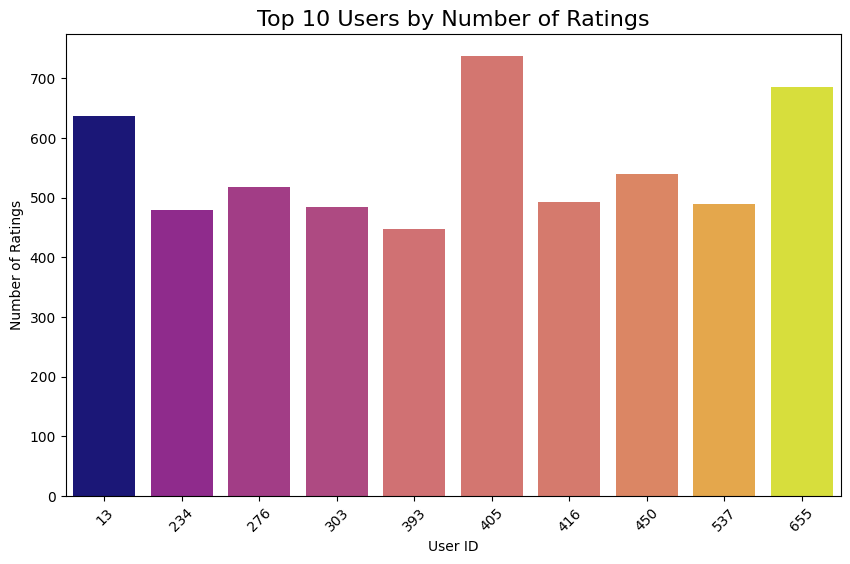

In [39]:
if 'df' in locals() and 'user_id' in df.columns:
    top_users = df['user_id'].value_counts().head(10)
    print("Top 10 Users by Number of Ratings:")
    display(top_users)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_users.index, y=top_users.values, hue=top_users.index, palette='plasma', legend=False)
    plt.title('Top 10 Users by Number of Ratings', fontsize=16)
    plt.xlabel('User ID')
    plt.ylabel('Number of Ratings')
    plt.xticks(rotation=45)
    plt.show()
    plt.close()
else:
    print("DataFrame 'df' or 'user_id' column not found. Cannot analyze top users.")

### 6. Top Items (Movies) by Number of Ratings

Top 10 Items by Number of Ratings:


,count
item_id,
50,583
258,509
100,508
181,507
294,485
286,481
288,478
1,452
300,431


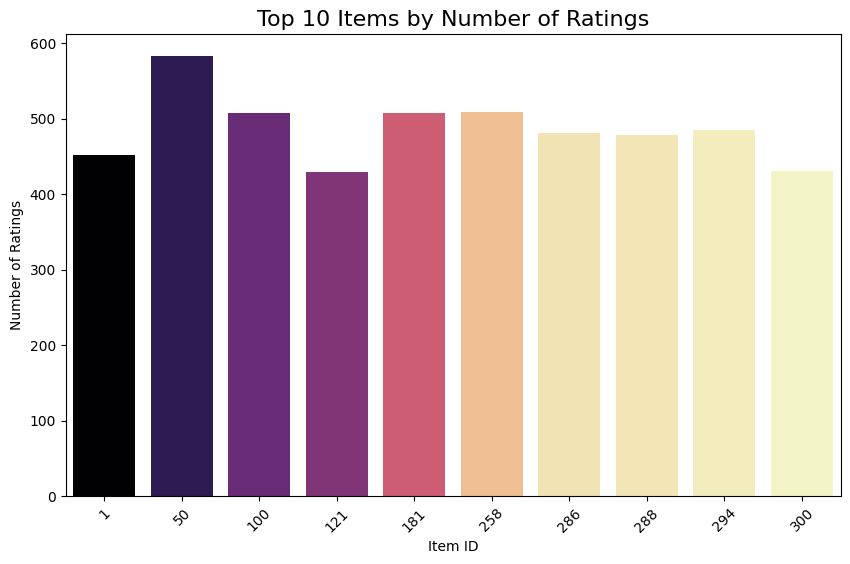

In [40]:
if 'df' in locals() and 'item_id' in df.columns:
    top_items = df['item_id'].value_counts().head(10)
    print("Top 10 Items by Number of Ratings:")
    display(top_items)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_items.index, y=top_items.values, hue=top_items.index, palette='magma', legend=False)
    plt.title('Top 10 Items by Number of Ratings', fontsize=16)
    plt.xlabel('Item ID')
    plt.ylabel('Number of Ratings')
    plt.xticks(rotation=45)
    plt.show()
    plt.close()
else:
    print("DataFrame 'df' or 'item_id' column not found. Cannot analyze top items.")

### 7. Average Rating per User and Item

Distribution of Average Ratings per User:


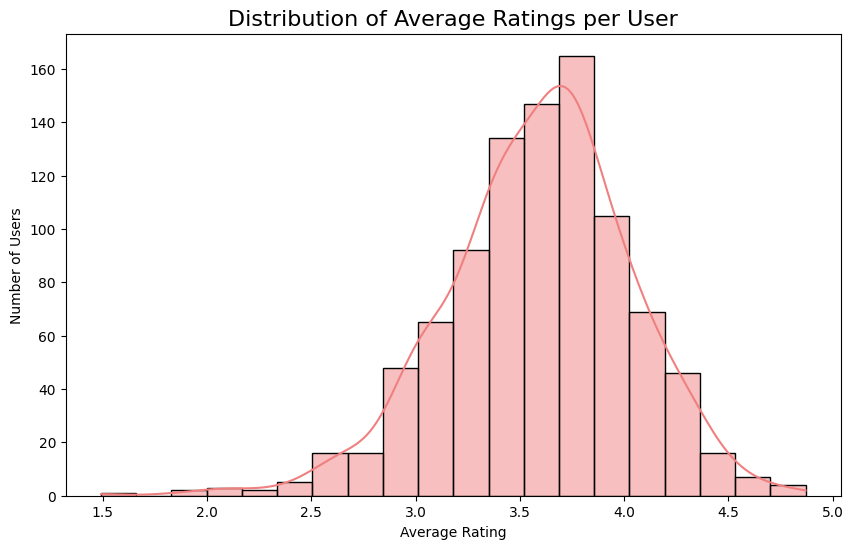


Distribution of Average Ratings per Item:


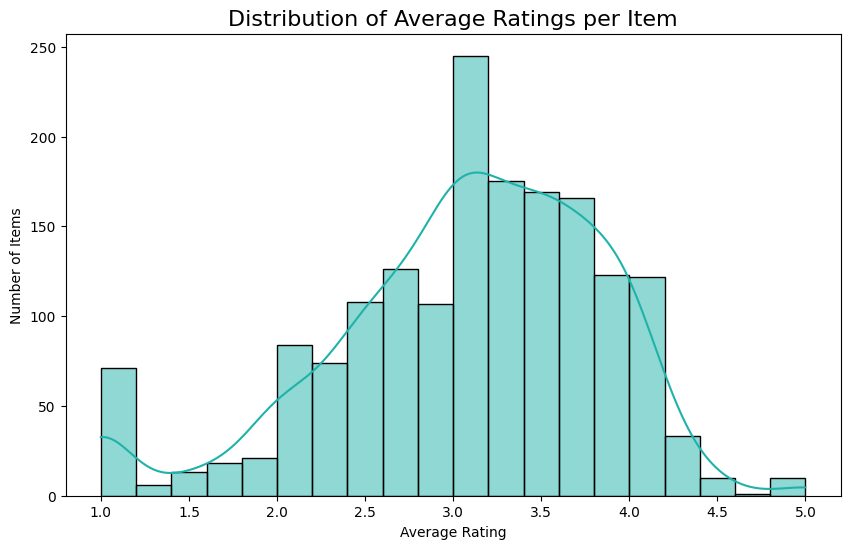

In [41]:
if 'df' in locals() and 'user_id' in df.columns and 'item_id' in df.columns and 'rating' in df.columns:
    avg_ratings_user = df.groupby('user_id')['rating'].mean()
    print("Distribution of Average Ratings per User:")
    plt.figure(figsize=(10, 6))
    sns.histplot(avg_ratings_user, bins=20, kde=True, color='lightcoral')
    plt.title('Distribution of Average Ratings per User', fontsize=16)
    plt.xlabel('Average Rating')
    plt.ylabel('Number of Users')
    plt.show()
    plt.close()

    avg_ratings_item = df.groupby('item_id')['rating'].mean()
    print("\nDistribution of Average Ratings per Item:")
    plt.figure(figsize=(10, 6))
    sns.histplot(avg_ratings_item, bins=20, kde=True, color='lightseagreen')
    plt.title('Distribution of Average Ratings per Item', fontsize=16)
    plt.xlabel('Average Rating')
    plt.ylabel('Number of Items')
    plt.show()
    plt.close()
else:
    print("DataFrame 'df' or required columns not found. Cannot analyze average ratings.")

### 8. Ratings over Time

Number of Ratings Over Time (Monthly):


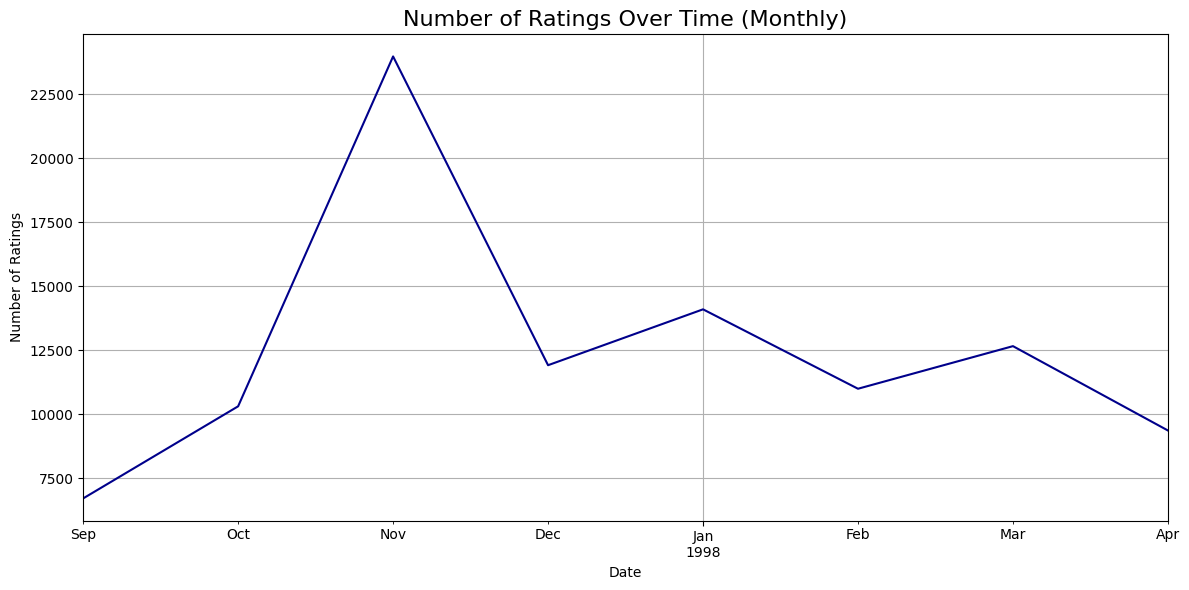

In [42]:
if 'df' in locals() and 'timestamp_dt' in df.columns:
    ratings_over_time = df.set_index('timestamp_dt').resample('ME')['rating'].count()
    print("Number of Ratings Over Time (Monthly):")
    plt.figure(figsize=(12, 6))
    ratings_over_time.plot(kind='line', color='darkblue')
    plt.title('Number of Ratings Over Time (Monthly)', fontsize=16)
    plt.xlabel('Date')
    plt.ylabel('Number of Ratings')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.close()
else:
    print("DataFrame 'df' or 'timestamp_dt' column not found. Cannot analyze ratings over time.")

### 9. Save Main Figures into a PDF Report for MovieLens

In [43]:
if 'df' in locals():
    pdf_filename_movielens = "MovieLens_EDA_Report.pdf"
    with PdfPages(pdf_filename_movielens) as pdf:

        if 'rating' in df.columns:
            fig_rating_dist = plt.figure(figsize=(8, 6))
            sns.countplot(x='rating', data=df, hue='rating', palette='viridis', legend=False)
            plt.title('Distribution of Movie Ratings', fontsize=16)
            plt.xlabel('Rating')
            plt.ylabel('Number of Ratings')
            pdf.savefig(fig_rating_dist)
            plt.close(fig_rating_dist)

        if 'user_id' in df.columns:
            top_users = df['user_id'].value_counts().head(10)
            fig_top_users = plt.figure(figsize=(10, 6))
            sns.barplot(x=top_users.index, y=top_users.values, hue=top_users.index, palette='plasma', legend=False)
            plt.title('Top 10 Users by Number of Ratings', fontsize=16)
            plt.xlabel('User ID')
            plt.ylabel('Number of Ratings')
            plt.xticks(rotation=45)
            plt.tight_layout()
            pdf.savefig(fig_top_users)
            plt.close(fig_top_users)

        if 'item_id' in df.columns:
            top_items = df['item_id'].value_counts().head(10)
            fig_top_items = plt.figure(figsize=(10, 6))
            sns.barplot(x=top_items.index, y=top_items.values, hue=top_items.index, palette='magma', legend=False)
            plt.title('Top 10 Items by Number of Ratings', fontsize=16)
            plt.xlabel('Item ID')
            plt.ylabel('Number of Ratings')
            plt.xticks(rotation=45)
            plt.tight_layout()
            pdf.savefig(fig_top_items)
            plt.close(fig_top_items)

        if 'user_id' in df.columns and 'rating' in df.columns:
            avg_ratings_user = df.groupby('user_id')['rating'].mean()
            fig_avg_user_rating = plt.figure(figsize=(10, 6))
            sns.histplot(avg_ratings_user, bins=20, kde=True, color='lightcoral')
            plt.title('Distribution of Average Ratings per User', fontsize=16)
            plt.xlabel('Average Rating')
            plt.ylabel('Number of Users')
            plt.tight_layout()
            pdf.savefig(fig_avg_user_rating)
            plt.close(fig_avg_user_rating)

        if 'item_id' in df.columns and 'rating' in df.columns:
            avg_ratings_item = df.groupby('item_id')['rating'].mean()
            fig_avg_item_rating = plt.figure(figsize=(10, 6))
            sns.histplot(avg_ratings_item, bins=20, kde=True, color='lightseagreen')
            plt.title('Distribution of Average Ratings per Item', fontsize=16)
            plt.xlabel('Average Rating')
            plt.ylabel('Number of Items')
            plt.tight_layout()
            pdf.savefig(fig_avg_item_rating)
            plt.close(fig_avg_item_rating)

        if 'timestamp_dt' in df.columns:
            ratings_over_time = df.set_index('timestamp_dt').resample('ME')['rating'].count()
            fig_ratings_time = plt.figure(figsize=(12, 6))
            ratings_over_time.plot(kind='line', color='darkblue')
            plt.title('Number of Ratings Over Time (Monthly)', fontsize=16)
            plt.xlabel('Date')
            plt.ylabel('Number of Ratings')
            plt.grid(True)
            plt.tight_layout()
            pdf.savefig(fig_ratings_time)
            plt.close(fig_ratings_time)

    print(f"All main figures saved to '{pdf_filename_movielens}'")
else:
    print("DataFrame 'df' not found. Cannot generate PDF report.")

All main figures saved to 'MovieLens_EDA_Report.pdf'


### (Obsolete) 3. Identify Numerical and Categorical Columns

### (Obsolete) 4. Correlation Matrix of Numerical Columns

### (Obsolete) 5. Annotated Correlation Heatmap

### (Obsolete) 6. Boxplots for Numerical Columns vs. PlacementStatus

### (Obsolete) 7. Heatmap Showing Missing Values

### (Obsolete) 8. Histograms for Specific Features

### (Obsolete) 9. Countplot for PlacementStatus by Specialisation

### (Obsolete) 10. Additional Numerical Correlation Heatmap (Same as before, ensuring it's included as requested)

### (Obsolete) 11. Boxplots for Specific Features

### (Obsolete) 12. Save Main Figures into a PDF Report